# Preprocessing — mask columns for modelling

Starting from `out_10km_idx.csv`, this notebook builds a set of **boolean
mask columns** that downstream modelling notebooks can use to filter pixels.
Nothing else is changed — the raw layers stay as they are. Output is written
to `out_10km_idx_preprocessed.csv`.

The masks fall into two groups:

1. **Exclusion masks** — pixels we almost always want to drop before
   modelling forest properties.
   - `is_no_forest`: `medelhojd_omdrev1 == 0` **and** `medelhojd_omdrev2 == 0`
     — non-forest in both inventory cycles (water, roads, fields, persistent
     clearings). Using *both* cycles avoids dropping pixels that were
     temporarily clear-cut in only one cycle.
   - `is_lake`: `markfuktighet_klassad == 4`. In this AOI the soil-moisture
     model's top class aligns with standing water.

2. **Disturbance masks** — pixels where cycle 2 is *lower* than cycle 1 for a
   given metric (`cycle2 - cycle1 < 0`). These identify clear-cuts, thinning
   and storm damage over the ~10 years between inventories. Useful either as
   **exclusions** (for steady-state growth models) or as **targets** (for
   change-detection / disturbance models).
   - `delta_neg_medelhojd`, `delta_neg_p95`, `delta_neg_medeldiameter`,
     `delta_neg_biomassa`, `delta_neg_volym`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 110

SRC = Path("out_10km_idx.csv")
DST = Path("out_10km_idx_preprocessed.csv")
assert SRC.exists(), f"Input not found: {SRC.resolve()}"

In [2]:
df = pd.read_csv(SRC)
print(df.shape)
df.head(3)

(641601, 36)


,x,y,biomassa_omdrev1,biomassa_omdrev2,flodesackumulering,grundyta_omdrev1,grundyta_omdrev2,markfuktighet,markfuktighet_klassad,medeldiameter_omdrev1,...,tradhojd,vegetationskvot_omdrev1,vegetationskvot_omdrev2,volym_omdrev1,volym_omdrev2,BK,PageName,Storruta,CenterLanNamn,CenterKommunNamn
0,445881.25,6260468.75,79.0,113.0,0.018730,22.0,23.0,97.0,2.0,15.0,...,142.0,83.0,88.0,127.0,162.0,6260_445_05,JA367,626_44,SKÅNE LÄN,OSBY
1,445893.75,6260468.75,65.0,96.0,0.121874,17.0,20.0,99.0,2.0,18.0,...,116.0,58.0,75.0,105.0,135.0,6260_445_05,JA367,626_44,SKÅNE LÄN,OSBY
2,445906.25,6260468.75,76.0,117.0,0.014839,21.0,24.0,99.0,2.0,15.0,...,138.0,80.0,88.0,117.0,162.0,6260_445_05,JA367,626_44,SKÅNE LÄN,OSBY


## 1. Exclusion masks

`is_no_forest` is intersected across both cycles to avoid flagging
transient clear-cuts as permanent non-forest. `is_lake` uses the user-observed
mapping that `markfuktighet_klassad == 4` corresponds to lakes in this AOI
(even though the nominal class label is `"moist"`).

In [3]:
df["is_no_forest"] = (df["medelhojd_omdrev1"] == 0) & (df["medelhojd_omdrev2"] == 0)
df["is_lake"] = df["markfuktighet_klassad"] == 4

excl_summary = pd.DataFrame({
    "n": [df["is_no_forest"].sum(), df["is_lake"].sum(),
          (df["is_no_forest"] | df["is_lake"]).sum()],
    "pct": [df["is_no_forest"].mean(), df["is_lake"].mean(),
            (df["is_no_forest"] | df["is_lake"]).mean()],
}, index=["is_no_forest", "is_lake", "union"])
excl_summary["pct"] = (excl_summary["pct"] * 100).round(2)
excl_summary

,n,pct
is_no_forest,63129,9.84
is_lake,3587,0.56
union,63944,9.97


## 2. Disturbance masks (negative cycle-to-cycle deltas)

`delta_neg_*` fires whenever the cycle-2 value is strictly less than cycle-1.
Heights and volumes can't be negative, so this only fires when cycle-1 was
positive — pixels that were non-forest in both cycles correctly don't count
as disturbed.

In [4]:
DELTA_VARS = ["medelhojd", "p95", "medeldiameter", "biomassa", "volym"]

for var in DELTA_VARS:
    diff = df[f"{var}_omdrev2"] - df[f"{var}_omdrev1"]
    df[f"delta_neg_{var}"] = diff < 0

delta_cols = [f"delta_neg_{v}" for v in DELTA_VARS]
df[delta_cols].sum().to_frame("n_pixels").assign(pct=lambda d: (d["n_pixels"] / len(df) * 100).round(2))

,n_pixels,pct
delta_neg_medelhojd,198504,30.94
delta_neg_p95,171665,26.76
delta_neg_medeldiameter,227988,35.53
delta_neg_biomassa,210559,32.82
delta_neg_volym,254705,39.70


Pixels flagged by k of 5 disturbance masks:


0    301652
1     79696
2     67141
3     38330
4     39457
5    115325
Name: count, dtype: int64

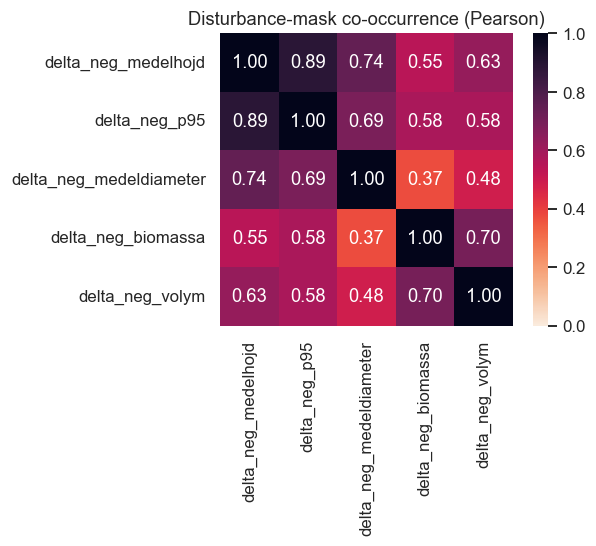

In [5]:
# How consistent are the 5 disturbance masks with each other?
disturb = df[delta_cols].astype(int)
corr = disturb.corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, vmin=0, vmax=1, cmap="rocket_r", annot=True, fmt=".2f", ax=ax, square=True)
ax.set_title("Disturbance-mask co-occurrence (Pearson)")
plt.tight_layout()

all_neg = disturb.sum(axis=1)
print("Pixels flagged by k of 5 disturbance masks:")
all_neg.value_counts().sort_index()

## 3. Spatial layout of each mask

In [6]:
def to_grid(column: str) -> np.ndarray:
    g = df.pivot(index="y", columns="x", values=column)
    return g.sort_index(ascending=False).values

extent = [df["x"].min(), df["x"].max(), df["y"].min(), df["y"].max()]

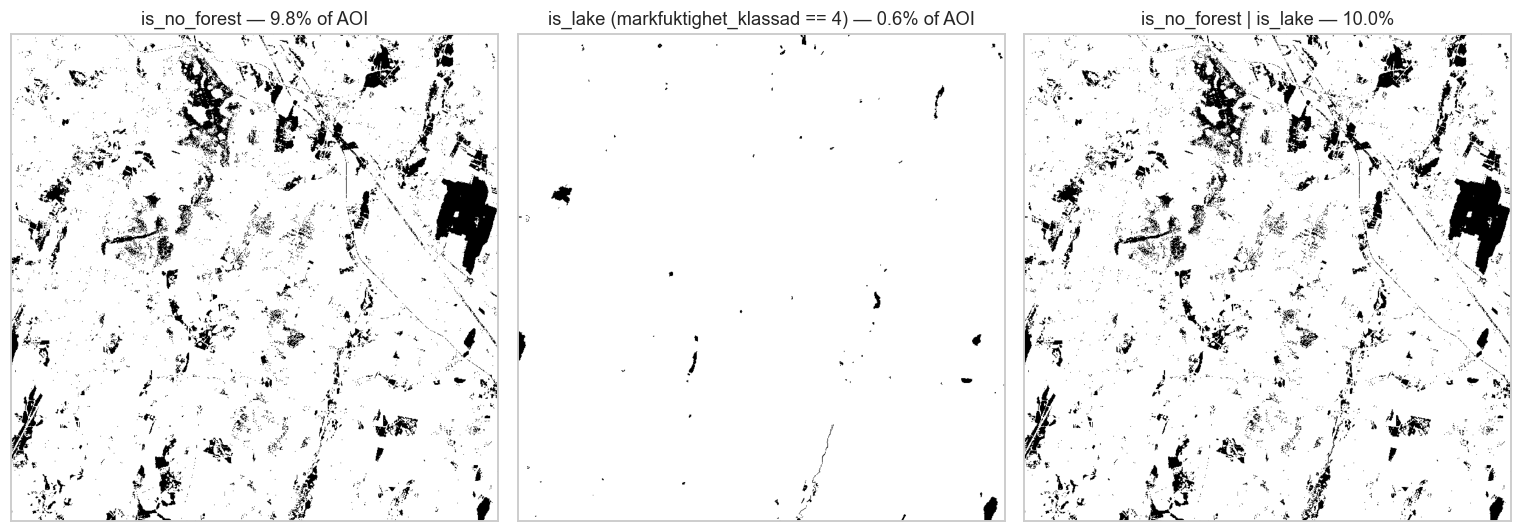

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col, title in zip(
    axes,
    ["is_no_forest", "is_lake"],
    ["is_no_forest", "is_lake (markfuktighet_klassad == 4)"],
):
    ax.imshow(to_grid(col).astype(float), cmap="gray_r", extent=extent, aspect="equal")
    ax.set_title(f"{title} — {df[col].mean()*100:.1f}% of AOI")
    ax.set_xticks([]); ax.set_yticks([])

combined = df["is_no_forest"] | df["is_lake"]
df["_combined"] = combined
axes[2].imshow(to_grid("_combined").astype(float), cmap="gray_r", extent=extent, aspect="equal")
axes[2].set_title(f"is_no_forest | is_lake — {combined.mean()*100:.1f}%")
axes[2].set_xticks([]); axes[2].set_yticks([])
df.drop(columns="_combined", inplace=True)
plt.tight_layout()

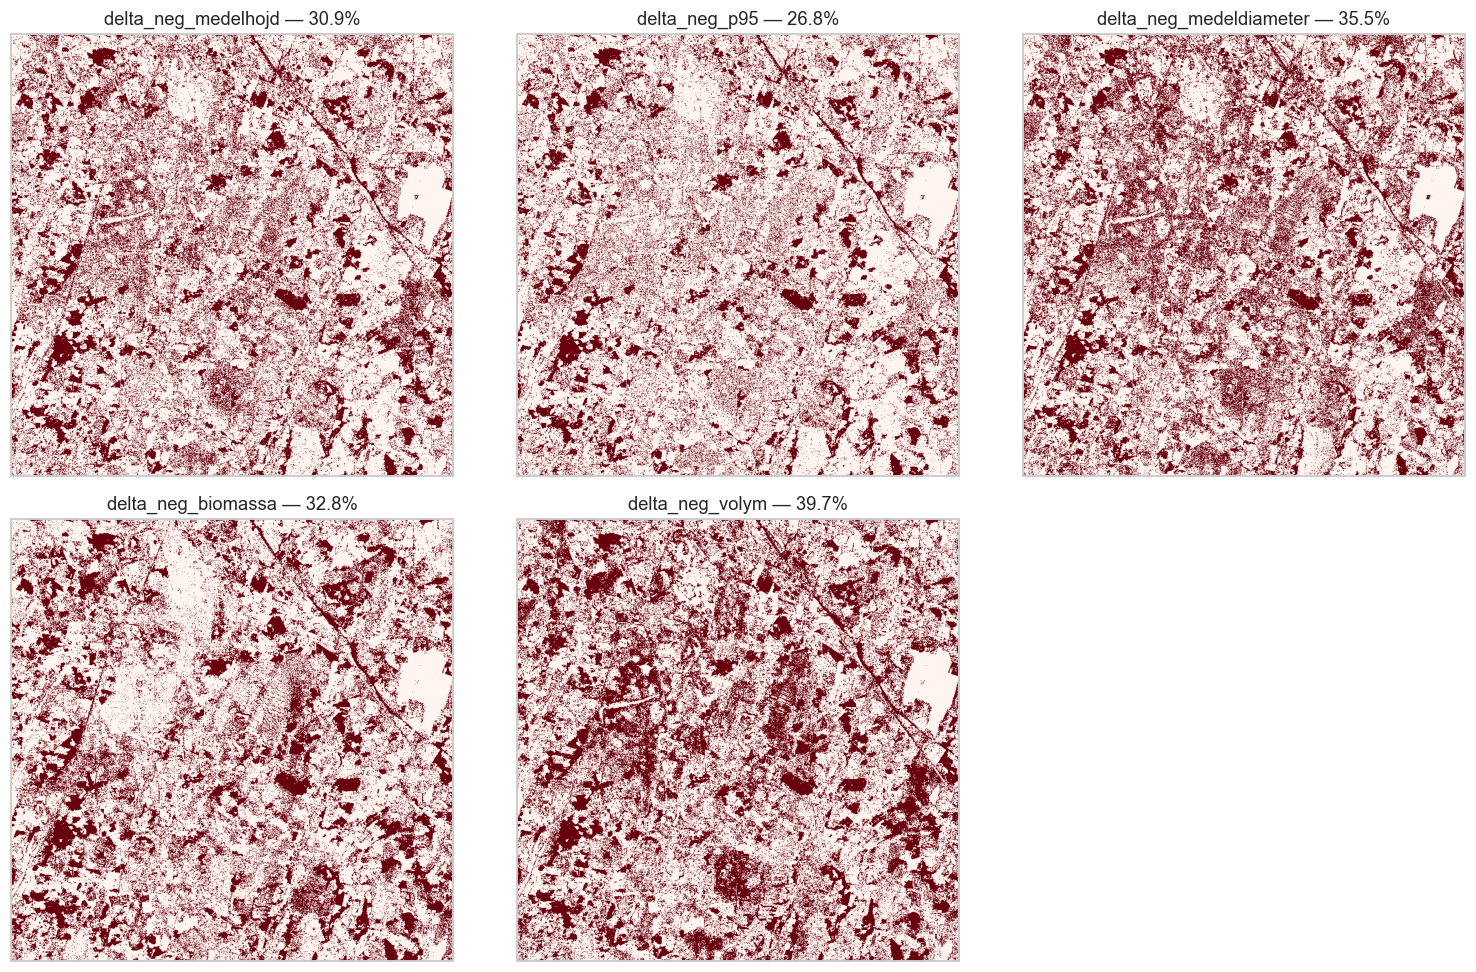

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, col in zip(axes.flat, delta_cols):
    ax.imshow(to_grid(col).astype(float), cmap="Reds", extent=extent, aspect="equal")
    ax.set_title(f"{col} — {df[col].mean()*100:.1f}%")
    ax.set_xticks([]); ax.set_yticks([])
axes.flat[-1].set_visible(False)
plt.tight_layout()

## 4. A recommended modelling mask

For a steady-state forest model we typically want pixels that are:

- Forest in both cycles (not `is_no_forest`).
- Not water (not `is_lake`).
- Not disturbed between cycles — a conservative choice is to drop anything
  flagged by *any* disturbance mask.

This is added as `is_stable_forest`. Users are free to build a looser mask
(e.g. `~is_no_forest & ~is_lake` only) from the primitive columns.

In [9]:
any_disturbance = df[delta_cols].any(axis=1)
df["is_stable_forest"] = (~df["is_no_forest"]) & (~df["is_lake"]) & (~any_disturbance)

pd.Series({
    "total": len(df),
    "is_no_forest": int(df["is_no_forest"].sum()),
    "is_lake": int(df["is_lake"].sum()),
    "any_disturbance": int(any_disturbance.sum()),
    "is_stable_forest": int(df["is_stable_forest"].sum()),
    "stable_pct": round(df["is_stable_forest"].mean() * 100, 2),
}).to_frame("value")

,value
total,641601.00
is_no_forest,63129.00
is_lake,3587.00
any_disturbance,339949.00
is_stable_forest,238129.00
stable_pct,37.11


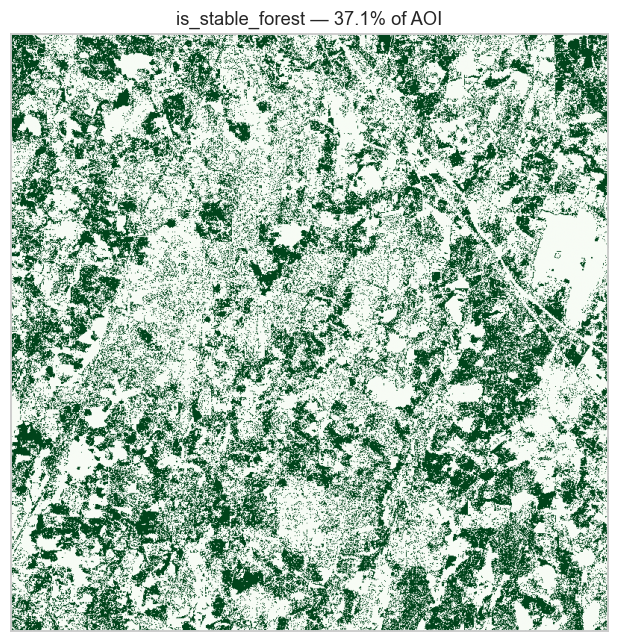

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(to_grid("is_stable_forest").astype(float), cmap="Greens", extent=extent, aspect="equal")
ax.set_title(f"is_stable_forest — {df['is_stable_forest'].mean()*100:.1f}% of AOI")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

## 5. Save the preprocessed CSV

In [11]:
new_cols = ["is_no_forest", "is_lake", *delta_cols, "is_stable_forest"]
print("Added columns:", new_cols)
print("Output shape:", df.shape)

df.to_csv(DST, index=False)
print(f"Wrote {DST}  ({DST.stat().st_size / 1e6:.1f} MB)")

Added columns: ['is_no_forest', 'is_lake', 'delta_neg_medelhojd', 'delta_neg_p95', 'delta_neg_medeldiameter', 'delta_neg_biomassa', 'delta_neg_volym', 'is_stable_forest']
Output shape: (641601, 44)
Wrote out_10km_idx_preprocessed.csv  (169.6 MB)
